# Central Tendency & Measures of Dispersion (Spread)

This notebook explains, with code and visuals, the two most fundamental ideas in descriptive statistics:

1. **Central tendency** – *"What is a typical value?"* (mean, median, mode, ...)
2. **Dispersion (spread)** – *"How much do the values differ from each other?"* (range, variance, standard deviation, IQR, ...)

**Contents**
1. Setup
2. Central tendency: mean, median, mode, weighted / trimmed / geometric / harmonic mean
3. Effect of outliers and skewness on the averages
4. Which measure should I use?
5. Dispersion: range, IQR, variance, std, MAD, CV
6. Population vs sample (Bessel's correction, `ddof`)
7. Outlier detection (IQR rule, Z-score)
8. Shape: skewness & kurtosis
9. Putting it together on a realistic dataset (pandas)
10. Summary cheat-sheet & practice exercises

## 1. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statistics

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=3, suppress=True)

## 2. Central Tendency

A **measure of central tendency** is a single number that summarises the "center" or "typical value" of a dataset.

We'll use a small dataset of marks scored by 10 students.

In [3]:
marks = np.array([45, 52, 58, 60, 62, 62, 65, 70, 75, 91])
print("Data:", marks)
print("n   :", len(marks))

Data: [45 52 58 60 62 62 65 70 75 91]
n   : 10


### 2.1 Mean (Arithmetic Average)

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

* Add all values, divide by the count.
* Uses **every** value, so it is very informative...
* ...but also **sensitive to outliers**.
* Balance point: the sum of deviations from the mean is always 0.

In [4]:
# Manual computation
mean_manual = sum(marks) / len(marks)

# Library versions
print("Manual  :", mean_manual)
print("NumPy   :", np.mean(marks))
print("Pandas  :", pd.Series(marks).mean())
print("statistics:", statistics.mean(marks))

# Property: deviations from the mean sum to zero
print("\nSum of deviations from mean:", round(np.sum(marks - marks.mean()), 10))

Manual  : 64.0
NumPy   : 64.0
Pandas  : 64.0
statistics: 64

Sum of deviations from mean: 0.0


### 2.2 Median (Middle Value)

* Sort the data. If `n` is odd → the middle value. If `n` is even → the average of the two middle values.
* **Robust** to outliers (extreme values hardly move it).
* Also called the 50th percentile (Q2).

In [5]:
sorted_marks = np.sort(marks)
n = len(sorted_marks)

# Manual median
if n % 2 == 1:
    median_manual = sorted_marks[n // 2]
else:
    median_manual = (sorted_marks[n // 2 - 1] + sorted_marks[n // 2]) / 2

print("Sorted :", sorted_marks)
print("Manual median :", median_manual, "(average of", sorted_marks[n//2 - 1], "and", sorted_marks[n//2], ")")
print("NumPy median  :", np.median(marks))

Sorted : [45 52 58 60 62 62 65 70 75 91]
Manual median : 62.0 (average of 62 and 62 )
NumPy median  : 62.0


### 2.3 Mode (Most Frequent Value)

* The value that appears most often.
* Works for **categorical** data too (the only average that does!).
* A dataset can have no mode, one mode (unimodal), or several (bimodal / multimodal).

In [6]:
from collections import Counter

counts = Counter(marks)
print("Frequencies:", dict(counts))

# statistics.multimode returns ALL modes
print("Mode(s):", statistics.multimode(marks))

# SciPy version
print("SciPy mode:", stats.mode(marks, keepdims=False))

# Mode works for categories
colors = ["red", "blue", "blue", "green", "red", "blue"]
print("Most common colour:", statistics.mode(colors))

# Bimodal example
print("Bimodal data modes:", statistics.multimode([1, 1, 2, 3, 3, 4]))

Frequencies: {np.int64(45): 1, np.int64(52): 1, np.int64(58): 1, np.int64(60): 1, np.int64(62): 2, np.int64(65): 1, np.int64(70): 1, np.int64(75): 1, np.int64(91): 1}
Mode(s): [np.int64(62)]
SciPy mode: ModeResult(mode=np.int64(62), count=np.int64(2))
Most common colour: blue
Bimodal data modes: [1, 3]


### 2.4 Visualising mean, median and mode together

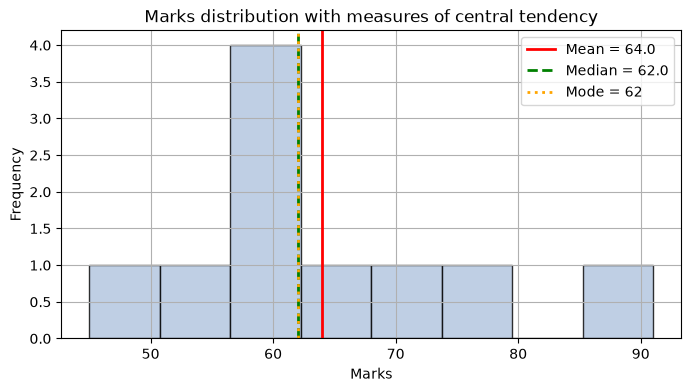

In [7]:
fig, ax = plt.subplots()
ax.hist(marks, bins=8, color="lightsteelblue", edgecolor="black", alpha=0.8)
ax.axvline(np.mean(marks),   color="red",    lw=2, label=f"Mean = {np.mean(marks):.1f}")
ax.axvline(np.median(marks), color="green",  lw=2, ls="--", label=f"Median = {np.median(marks):.1f}")
ax.axvline(statistics.mode(marks), color="orange", lw=2, ls=":", label=f"Mode = {statistics.mode(marks)}")
ax.set_title("Marks distribution with measures of central tendency")
ax.set_xlabel("Marks"); ax.set_ylabel("Frequency")
ax.legend()
plt.show()

### 2.5 Other useful averages

**Weighted mean** – some values count more than others (e.g., course grades with credit weights):

$$\bar{x}_w = \frac{\sum w_i x_i}{\sum w_i}$$

In [8]:
scores  = np.array([80, 90, 70])        # Exam, Project, Quiz
weights = np.array([0.5, 0.3, 0.2])     # importance

print("Simple mean  :", scores.mean())
print("Weighted mean:", np.average(scores, weights=weights))

Simple mean  : 80.0
Weighted mean: 81.0


**Trimmed mean** – drop a percentage of the smallest and largest values, then average. A compromise between mean and median.

In [9]:
# Trim 10% from each end (removes 1 value at each end of our 10 marks)
print("Mean          :", marks.mean())
print("10% trimmed   :", stats.trim_mean(marks, 0.1))
print("Median        :", np.median(marks))

Mean          : 64.0
10% trimmed   : 63.0
Median        : 62.0


**Geometric mean** – best for **growth rates / ratios / percentages** that multiply:

$$GM = \left(\prod x_i\right)^{1/n}$$

Example: an investment grows +10%, +20%, -5% in three years. The average yearly growth is *not* the arithmetic mean.

In [10]:
growth_factors = np.array([1.10, 1.20, 0.95])  # +10%, +20%, -5%

am = growth_factors.mean()
gm = stats.gmean(growth_factors)

print(f"Arithmetic mean factor: {am:.4f}  -> {100*(am-1):.2f}% / year")
print(f"Geometric  mean factor: {gm:.4f}  -> {100*(gm-1):.2f}% / year")

# Verify: applying GM three times reproduces the true total growth
print("True total growth      :", np.prod(growth_factors))
print("GM ** 3                :", gm ** 3)
print("AM ** 3 (overstates!)  :", am ** 3)

Arithmetic mean factor: 1.0833  -> 8.33% / year
Geometric  mean factor: 1.0784  -> 7.84% / year
True total growth      : 1.254
GM ** 3                : 1.2540000000000002
AM ** 3 (overstates!)  : 1.2714120370370368


**Harmonic mean** – best for **rates / speeds / ratios** over equal distances:

$$HM = \frac{n}{\sum \frac{1}{x_i}}$$

Example: you drive to a city at 60 km/h and return at 40 km/h. Average speed?

In [11]:
speeds = np.array([60, 40])
print("Arithmetic mean speed:", speeds.mean(), "km/h  (WRONG for this case)")
print("Harmonic  mean speed :", stats.hmean(speeds), "km/h  (correct)")

# Check: 2 * distance / total time. Take distance = 120 km each way
d = 120
total_time = d/60 + d/40
print("True average speed   :", 2*d/total_time, "km/h")

Arithmetic mean speed: 50.0 km/h  (WRONG for this case)
Harmonic  mean speed : 47.99999999999999 km/h  (correct)
True average speed   : 48.0 km/h


## 3. Effect of Outliers and Skewness

An **outlier** is a value far from the rest. Watch how the mean reacts, while the median barely moves.

In [12]:
salaries = np.array([30, 32, 35, 36, 38, 40, 42, 45])   # in thousands
salaries_outlier = np.append(salaries, 400)              # add a CEO

df = pd.DataFrame({
    "Without outlier": [salaries.mean(), np.median(salaries)],
    "With outlier":    [salaries_outlier.mean(), np.median(salaries_outlier)],
}, index=["Mean", "Median"])
df

,Without outlier,With outlier
Mean,37.25,77.555556
Median,37.00,38.000000


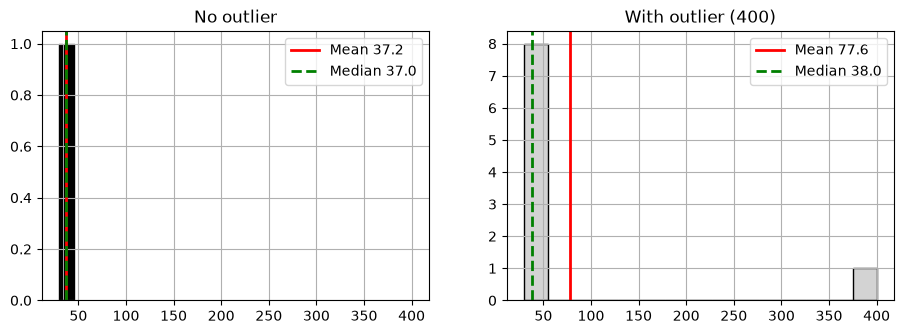

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharex=True)
for ax, data, title in zip(axes, [salaries, salaries_outlier], ["No outlier", "With outlier (400)"]):
    ax.hist(data, bins=15, color="lightgray", edgecolor="black")
    ax.axvline(data.mean(), color="red", lw=2, label=f"Mean {data.mean():.1f}")
    ax.axvline(np.median(data), color="green", lw=2, ls="--", label=f"Median {np.median(data):.1f}")
    ax.set_title(title); ax.legend()
plt.show()

### Mean vs Median vs Mode and the *shape* of a distribution

| Shape | Relationship | Tail |
|---|---|---|
| Symmetric | mean ≈ median ≈ mode | balanced |
| Right (positive) skew | mean > median > mode | long tail to the right |
| Left (negative) skew | mean < median < mode | long tail to the left |

The mean is "pulled" toward the tail.

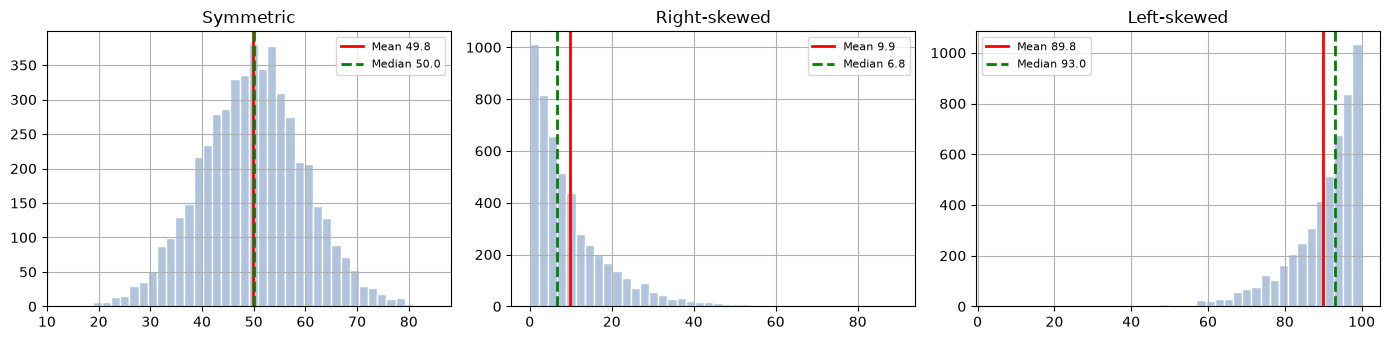

In [14]:
rng = np.random.default_rng(42)

symmetric  = rng.normal(50, 10, 5000)
right_skew = rng.exponential(scale=10, size=5000)
left_skew  = 100 - rng.exponential(scale=10, size=5000)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, data, title in zip(axes, [symmetric, right_skew, left_skew],
                           ["Symmetric", "Right-skewed", "Left-skewed"]):
    ax.hist(data, bins=40, color="lightsteelblue", edgecolor="white")
    ax.axvline(data.mean(), color="red", lw=2, label=f"Mean {data.mean():.1f}")
    ax.axvline(np.median(data), color="green", lw=2, ls="--", label=f"Median {np.median(data):.1f}")
    ax.set_title(title); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Which measure should I use?

| Situation | Best measure |
|---|---|
| Symmetric numeric data, no outliers | **Mean** |
| Skewed data or outliers (income, house prices) | **Median** |
| Categorical / nominal data (colour, brand) | **Mode** |
| Growth rates, compound returns | **Geometric mean** |
| Rates and speeds (equal distance) | **Harmonic mean** |
| Values with different importance | **Weighted mean** |
| Want robustness + some use of all data | **Trimmed mean** |

## 5. Measures of Dispersion (Spread)

Central tendency alone can be **misleading**. Two datasets can have the same mean but be totally different.

Mean A: 50.0 | Mean B: 50.0


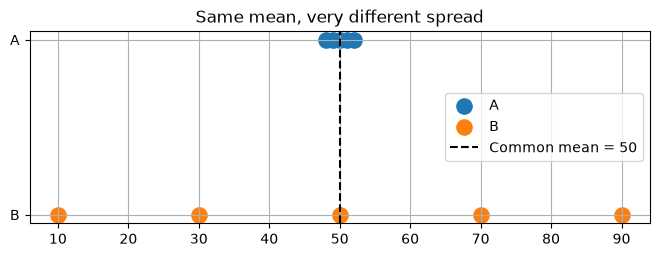

In [15]:
A = np.array([48, 49, 50, 51, 52])       # tightly packed
B = np.array([10, 30, 50, 70, 90])       # widely spread

print("Mean A:", A.mean(), "| Mean B:", B.mean())

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.scatter(A, np.ones_like(A), s=120, label="A", color="tab:blue")
ax.scatter(B, np.zeros_like(B), s=120, label="B", color="tab:orange")
ax.axvline(50, color="k", ls="--", label="Common mean = 50")
ax.set_yticks([0, 1]); ax.set_yticklabels(["B", "A"])
ax.set_title("Same mean, very different spread"); ax.legend(loc="center right")
plt.show()

### 5.1 Range

$$\text{Range} = \max - \min$$

Simple, but depends only on 2 values and is very sensitive to outliers.

In [16]:
for name, d in [("A", A), ("B", B)]:
    print(f"{name}: min={d.min()}, max={d.max()}, range={np.ptp(d)}")

A: min=48, max=52, range=4
B: min=10, max=90, range=80


### 5.2 Quartiles and Interquartile Range (IQR)

* **Q1** = 25th percentile, **Q2** = median, **Q3** = 75th percentile.
* $IQR = Q3 - Q1$ → the spread of the **middle 50%** of the data.
* Robust to outliers.

In [17]:
q1, q2, q3 = np.percentile(marks, [25, 50, 75])
iqr = q3 - q1
print(f"Q1 = {q1}, Q2 (median) = {q2}, Q3 = {q3}")
print(f"IQR = {iqr}")

# SciPy shortcut
print("scipy.stats.iqr:", stats.iqr(marks))

Q1 = 58.5, Q2 (median) = 62.0, Q3 = 68.75
IQR = 10.25
scipy.stats.iqr: 10.25


### 5.3 Variance

Average of the **squared** deviations from the mean.

$$\sigma^2 = \frac{1}{N}\sum (x_i-\mu)^2 \quad \text{(population)} \qquad s^2 = \frac{1}{n-1}\sum (x_i-\bar{x})^2 \quad \text{(sample)}$$

Why square? Plain deviations cancel out (sum to zero). Squaring makes them positive and penalises big deviations more.
The units of variance are **squared** units (e.g., marks²), which is hard to interpret. That's why we use the standard deviation.

In [18]:
mean = marks.mean()
deviations = marks - mean
squared_dev = deviations ** 2

table = pd.DataFrame({"x": marks, "x - mean": deviations, "(x - mean)^2": squared_dev})
print(table.to_string(index=False))

pop_var    = squared_dev.sum() / len(marks)
sample_var = squared_dev.sum() / (len(marks) - 1)
print(f"\nPopulation variance (÷N)   : {pop_var:.3f}")
print(f"Sample variance     (÷n-1) : {sample_var:.3f}")

 x  x - mean  (x - mean)^2
45     -19.0         361.0
52     -12.0         144.0
58      -6.0          36.0
60      -4.0          16.0
62      -2.0           4.0
62      -2.0           4.0
65       1.0           1.0
70       6.0          36.0
75      11.0         121.0
91      27.0         729.0

Population variance (÷N)   : 145.200
Sample variance     (÷n-1) : 161.333


### 5.4 Standard Deviation

$$\sigma = \sqrt{\sigma^2}$$

* Square root of variance → **same units as the data**.
* Interpretation: the typical distance of a value from the mean.
* For a bell-shaped (normal) distribution, the **68–95–99.7 rule** applies:
  * ~68% of data within ±1σ
  * ~95% within ±2σ
  * ~99.7% within ±3σ

In [19]:
pop_std    = np.std(marks)            # ddof=0 by default
sample_std = np.std(marks, ddof=1)    # sample

print(f"Population std: {pop_std:.3f}")
print(f"Sample std    : {sample_std:.3f}")
print("Pandas (default is sample, ddof=1):", pd.Series(marks).std())

Population std: 12.050
Sample std    : 12.702
Pandas (default is sample, ddof=1): 12.701705922171767


Within ±1 std: 68.40%
Within ±2 std: 95.46%
Within ±3 std: 99.71%


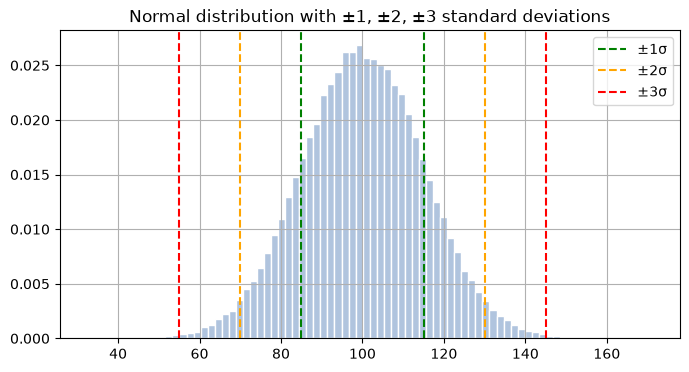

In [20]:
# Demonstrate 68-95-99.7 rule on simulated normal data
rng = np.random.default_rng(0)
x = rng.normal(loc=100, scale=15, size=100_000)
mu, sd = x.mean(), x.std()

for k in (1, 2, 3):
    pct = np.mean((x > mu - k*sd) & (x < mu + k*sd)) * 100
    print(f"Within ±{k} std: {pct:.2f}%")

fig, ax = plt.subplots()
ax.hist(x, bins=80, color="lightsteelblue", edgecolor="white", density=True)
for k, c in zip((1, 2, 3), ("green", "orange", "red")):
    ax.axvline(mu - k*sd, color=c, ls="--"); ax.axvline(mu + k*sd, color=c, ls="--", label=f"±{k}σ")
ax.set_title("Normal distribution with ±1, ±2, ±3 standard deviations"); ax.legend()
plt.show()

### 5.5 Mean Absolute Deviation (MAD) and Median Absolute Deviation

* **Mean absolute deviation:** average of $|x_i - \bar{x}|$ — easier to interpret than std.
* **Median absolute deviation:** median of $|x_i - \text{median}|$ — very **robust** to outliers.

In [21]:
mean_abs_dev   = np.mean(np.abs(marks - marks.mean()))
median_abs_dev = stats.median_abs_deviation(marks)   # raw (unscaled)

print(f"Mean absolute deviation  : {mean_abs_dev:.3f}")
print(f"Median absolute deviation: {median_abs_dev:.3f}")

Mean absolute deviation  : 9.000
Median absolute deviation: 6.000


### 5.6 Coefficient of Variation (CV)

$$CV = \frac{\sigma}{\mu} \times 100\%$$

A **unit-free** measure, so you can compare spread between datasets with different units or scales
(e.g., heights in cm vs weights in kg).

In [22]:
heights = np.array([160, 165, 170, 175, 180])   # cm
weights = np.array([50, 60, 70, 80, 100])       # kg

cv = lambda d: np.std(d, ddof=1) / np.mean(d) * 100

print(f"Height: mean={heights.mean():.1f}, std={heights.std(ddof=1):.2f}, CV={cv(heights):.2f}%")
print(f"Weight: mean={weights.mean():.1f}, std={weights.std(ddof=1):.2f}, CV={cv(weights):.2f}%")
print("\n-> Weight varies much more relative to its average.")
print("SciPy variation:", stats.variation(weights, ddof=1) * 100)

Height: mean=170.0, std=7.91, CV=4.65%
Weight: mean=72.0, std=19.24, CV=26.72%

-> Weight varies much more relative to its average.
SciPy variation: 26.71581119676576


## 6. Population vs Sample: Why `n - 1`? (Bessel's Correction)

* **Population** = every member of the group (use ÷ N).
* **Sample** = a subset drawn from the population (use ÷ n-1).

A sample's values are on average closer to the *sample* mean than to the true population mean, so dividing by `n` **underestimates** variance. Dividing by `n-1` fixes this bias. Let's verify by simulation.

In [23]:
rng = np.random.default_rng(1)
population = rng.normal(50, 10, 100_000)
true_var = population.var()
print("True population variance:", round(true_var, 2))

biased, unbiased = [], []
for _ in range(20000):
    s = rng.choice(population, size=5)      # small samples
    biased.append(np.var(s, ddof=0))
    unbiased.append(np.var(s, ddof=1))

print("Average of ÷n   estimates:", round(np.mean(biased), 2),   "(too low)")
print("Average of ÷n-1 estimates:", round(np.mean(unbiased), 2), "(close to truth)")

True population variance: 99.31
Average of ÷n   estimates: 79.77 (too low)
Average of ÷n-1 estimates: 99.71 (close to truth)


**Rule of thumb in code**

| Library | Default | To get sample variance/std |
|---|---|---|
| NumPy `np.var / np.std` | `ddof=0` (population) | `ddof=1` |
| Pandas `.var() / .std()` | `ddof=1` (sample) | already sample |
| `statistics.variance / stdev` | sample | `pvariance / pstdev` for population |

## 7. Detecting Outliers

### 7.1 IQR (Tukey) rule
A point is an outlier if it is outside:

$$[\,Q_1 - 1.5\times IQR,\;\; Q_3 + 1.5\times IQR\,]$$

Q1=14.25, Q3=17.75, IQR=3.5
Fences: [9.0, 23.0]
Outliers: [60]


C:\Users\praja\AppData\Local\Temp\ipykernel_30916\4037075275.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=False, whis=1.5)


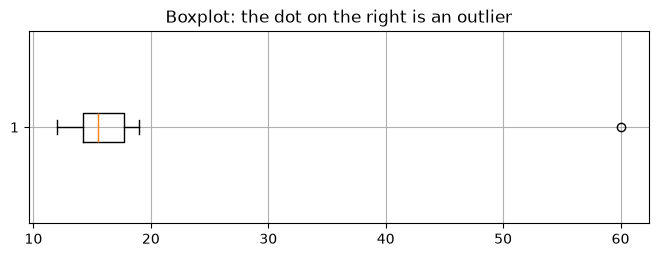

In [24]:
data = np.array([12, 13, 14, 15, 15, 16, 17, 18, 19, 60])

q1, q3 = np.percentile(data, [25, 75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
print(f"Q1={q1}, Q3={q3}, IQR={iqr}")
print(f"Fences: [{lower}, {upper}]")
print("Outliers:", data[(data < lower) | (data > upper)])

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.boxplot(data, vert=False, whis=1.5)
ax.set_title("Boxplot: the dot on the right is an outlier")
plt.show()

### 7.2 Z-score

$$z = \frac{x - \mu}{\sigma}$$

Tells you **how many standard deviations** a value is from the mean. Common rule: |z| > 3 is an outlier (|z| > 2 is "unusual").

Note: the mean and std are themselves affected by outliers, so z-scores can *mask* outliers in small datasets.

In [25]:
z = stats.zscore(data)
result = pd.DataFrame({"value": data, "z-score": z.round(2)})
print(result.to_string(index=False))
print("\nMax |z| =", np.abs(z).max().round(2), "-> in a tiny dataset a z of 3 is hard to reach; the outlier inflates std itself!")

 value  z-score
    12    -0.58
    13    -0.51
    14    -0.44
    15    -0.36
    15    -0.36
    16    -0.29
    17    -0.21
    18    -0.14
    19    -0.07
    60     2.97

Max |z| = 2.97 -> in a tiny dataset a z of 3 is hard to reach; the outlier inflates std itself!


## 8. Shape of the Distribution: Skewness & Kurtosis

**Skewness** measures asymmetry.
* 0 → symmetric, > 0 → right-skewed, < 0 → left-skewed.

**Kurtosis** measures how heavy the tails are (SciPy reports *excess* kurtosis: normal = 0).
* > 0 → heavy tails (more outliers), < 0 → light tails.

In [26]:
rng = np.random.default_rng(7)
datasets = {
    "Normal":        rng.normal(0, 1, 10000),
    "Right-skewed":  rng.exponential(1, 10000),
    "Left-skewed":   -rng.exponential(1, 10000),
    "Heavy-tailed (t, df=3)": rng.standard_t(3, 10000),
    "Light-tailed (uniform)": rng.uniform(-2, 2, 10000),
}

summary = pd.DataFrame({
    name: {"skewness": stats.skew(d), "excess kurtosis": stats.kurtosis(d)}
    for name, d in datasets.items()
}).T.round(2)
summary

,skewness,excess kurtosis
Normal,0.01,0.00
Right-skewed,1.93,5.25
Left-skewed,-1.98,5.82
"Heavy-tailed (t, df=3)",0.20,10.21
Light-tailed (uniform),0.00,-1.19


## 9. Putting It All Together on a Realistic Dataset

Let's create a synthetic dataset of employees and use pandas to summarise it.

In [27]:
rng = np.random.default_rng(123)
n = 300

df = pd.DataFrame({
    "department": rng.choice(["Sales", "Engineering", "HR"], size=n, p=[0.4, 0.4, 0.2]),
    "age": rng.normal(35, 7, n).round().astype(int),
    "salary": np.round(rng.lognormal(mean=10.8, sigma=0.4, size=n), -2),   # right-skewed
})
df.head()

,department,age,salary
0,Engineering,39,94200.0
1,Sales,32,47600.0
2,Sales,39,69000.0
3,Sales,28,42900.0
4,Sales,26,19200.0


In [28]:
# One-line summary
df[["age", "salary"]].describe().round(1)

,age,salary
count,300.0,300.0
mean,34.9,54021.0
std,7.3,22453.4
min,12.0,18600.0
25%,30.0,38150.0
50%,35.0,49500.0
75%,40.0,65900.0
max,53.0,166600.0


In [29]:
# Central tendency & spread side by side
def summarize(s):
    return pd.Series({
        "mean": s.mean(),
        "median": s.median(),
        "mode": s.mode().iloc[0],
        "range": s.max() - s.min(),
        "IQR": s.quantile(0.75) - s.quantile(0.25),
        "variance": s.var(),
        "std": s.std(),
        "CV %": s.std() / s.mean() * 100,
        "skew": s.skew(),
        "kurtosis": s.kurt(),
    })

df[["age", "salary"]].apply(summarize).round(2)

,age,salary
mean,34.85,5.402100e+04
median,35.00,4.950000e+04
mode,37.00,4.360000e+04
range,41.00,1.480000e+05
IQR,10.00,2.775000e+04
variance,53.08,5.041550e+08
std,7.29,2.245340e+04
CV %,20.90,4.156000e+01
skew,-0.25,1.240000e+00
kurtosis,-0.12,2.730000e+00


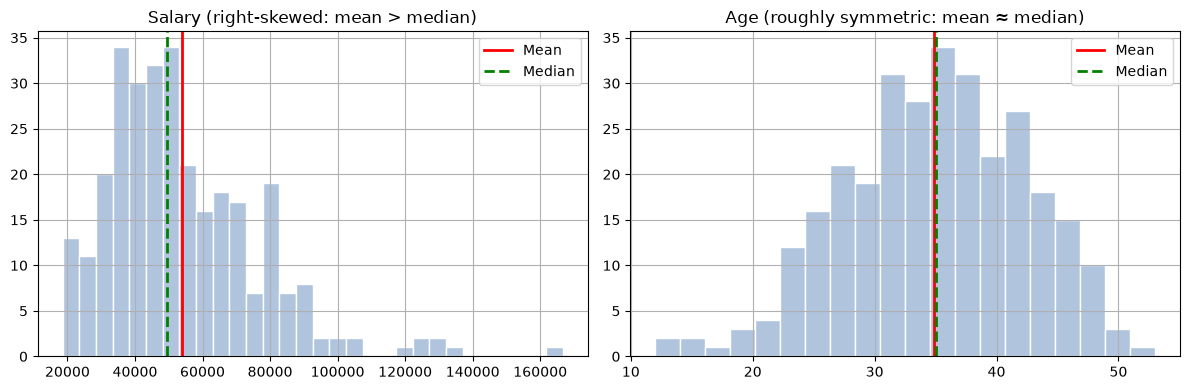

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["salary"], bins=30, color="lightsteelblue", edgecolor="white")
axes[0].axvline(df["salary"].mean(),   color="red",   lw=2, label="Mean")
axes[0].axvline(df["salary"].median(), color="green", lw=2, ls="--", label="Median")
axes[0].set_title("Salary (right-skewed: mean > median)"); axes[0].legend()

axes[1].hist(df["age"], bins=20, color="lightsteelblue", edgecolor="white")
axes[1].axvline(df["age"].mean(),   color="red",   lw=2, label="Mean")
axes[1].axvline(df["age"].median(), color="green", lw=2, ls="--", label="Median")
axes[1].set_title("Age (roughly symmetric: mean ≈ median)"); axes[1].legend()
plt.tight_layout(); plt.show()

In [31]:
# Group-wise statistics
df.groupby("department")["salary"].agg(["count", "mean", "median", "std", "min", "max"]).round(0)

,count,mean,median,std,min,max
department,,,,,,
Engineering,116,50765.0,47400.0,19691.0,18600.0,129100.0
HR,57,55954.0,54800.0,23525.0,19300.0,130600.0
Sales,127,56128.0,49900.0,24095.0,19100.0,166600.0


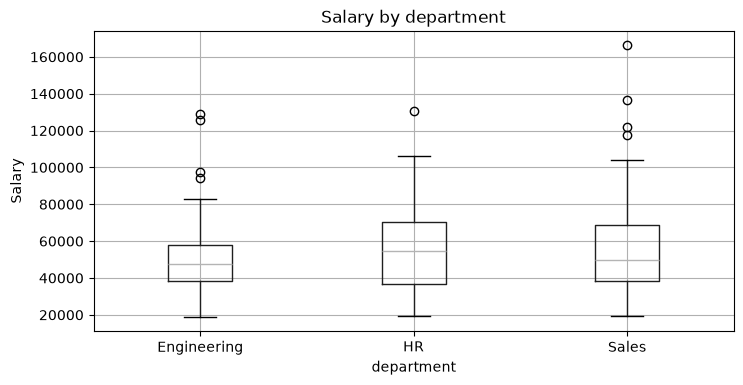

In [32]:
# Boxplot compares medians and spreads across groups at a glance
df.boxplot(column="salary", by="department", figsize=(8, 4))
plt.suptitle(""); plt.title("Salary by department"); plt.ylabel("Salary")
plt.show()

## 10. Summary Cheat-Sheet

### Central tendency
| Measure | Formula / idea | Robust to outliers? | Best for |
|---|---|---|---|
| Mean | Σx / n | No | Symmetric numeric data |
| Median | Middle value | **Yes** | Skewed data |
| Mode | Most frequent | Yes | Categorical data |
| Weighted mean | Σwx / Σw | No | Unequal importance |
| Trimmed mean | Mean after cutting tails | Mostly | Compromise |
| Geometric mean | (Πx)^(1/n) | No | Growth rates |
| Harmonic mean | n / Σ(1/x) | No | Rates, speeds |

### Dispersion
| Measure | Formula / idea | Robust? | Units |
|---|---|---|---|
| Range | max − min | No | Same as data |
| IQR | Q3 − Q1 | **Yes** | Same as data |
| Variance | Σ(x−mean)² / (n−1) | No | Squared |
| Std deviation | √variance | No | Same as data |
| Mean abs. deviation | mean of \|x−mean\| | Somewhat | Same as data |
| Median abs. deviation | median of \|x−median\| | **Yes** | Same as data |
| Coefficient of variation | std / mean | No | Unitless |

### Key takeaways
1. **Always report a measure of center AND a measure of spread.** One without the other is incomplete.
2. Use **mean + std** for symmetric data; use **median + IQR** for skewed data or data with outliers.
3. Mean is pulled toward the tail: right-skew → mean > median; left-skew → mean < median.
4. Use `ddof=1` (÷ n−1) for **sample** variance/std to get an unbiased estimate.
5. Use **CV** to compare variability across different units or scales.
6. Always **visualise** (histogram, boxplot) — summary numbers can hide the shape.

## Practice Exercises

1. Compute the mean, median, mode, variance, std and IQR of `[4, 8, 15, 16, 23, 42]` by hand and verify in code.
2. Create a dataset where the **mean equals the median** but the standard deviation is very large.
3. Add an outlier to any dataset and compare how much the mean, median, std and IQR each change. Which are most stable?
4. A stock returns +50%, -50% over two years. Compute the arithmetic and geometric mean return. Which describes your actual outcome?
5. Two classes: Class A mean = 70, std = 5; Class B mean = 70, std = 20. Describe the difference in plain English and plot them.
6. Use the employee dataset above: which department has the highest salary **CV**?